## AGROLAB AI - STRAWBERRY DATA GENERATION & EXPLORATORY DATA ANALYSIS (EDA)

Iniciação Científica - Simulador de Sensores IoT com base nas regras do Morango

In [19]:
# !pip install pandas numpy scikit-learn matplotlib seaborn jupyter

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [5]:
# Configurando a semente aleatória para reprodutibilidade científica
np.random.seed(42)

Definição dos Parâmetros Base

In [6]:
num_registros = 5000  # Número de leituras de sensores (ex: leituras de hora em hora)
data_inicial = datetime(2026, 6, 1, 0, 0)

In [7]:
# Criando a linha do tempo (Timestamps)
timestamps = [data_inicial + timedelta(hours=i) for i in range(num_registros)]

Geração Sintética das Features com Correlação Física

In [8]:
# 3.1. Temperatura Ambiente (°C) - Flutuação diária normal + ruído
# Simula temperaturas mais frias de madrugada e mais quentes às 14h
horas = np.array([ts.hour for ts in timestamps])
temp_ambiente = 22 + 7 * np.sin((horas - 8) * 2 * np.pi / 24) + np.random.normal(0, 1.5, num_registros)

# 3.2. Temperatura do Solo (°C) - Segue a ambiente com um atraso térmico e menos variação
temp_solo = 19 + 4 * np.sin((horas - 10) * 2 * np.pi / 24) + np.random.normal(0, 0.8, num_registros)

# 3.3. Umidade do Solo (%) - Inversamente proporcional à temperatura (evaporação)
# Começa estável e flutua. Valores mais altos de temperatura derrubam a umidade.
umidade_solo = 70 - (temp_ambiente - 22) * 1.2 + np.random.normal(0, 5, num_registros)
umidade_solo = np.clip(umidade_solo, 20, 100) # Mantém nos limites físicos de 0-100%

# 3.4. pH do Solo - Flutua levemente ao redor do ideal do morango (5.5 a 6.2)
ph_solo = np.random.normal(5.8, 0.4, num_registros)
ph_solo = np.clip(ph_solo, 4.0, 8.5)

# 3.5. Macronutrientes NPK (mg/L) - Baseado nas faixas ideais do documento
nitrogenio = np.random.normal(200, 30, num_registros) # Ideal: 150-250
fosforo = np.random.normal(45, 10, num_registros)     # Ideal: 30-60
potassio = np.random.normal(275, 40, num_registros)   # Ideal: 200-350

Engenharia de Labels (Criando as Classes do Jogo da IA)

In [9]:
labels = []

In [10]:
for i in range(num_registros):
    # Regra para classe 3: Proteger (Extremos de Temperatura no Morango)
    if temp_ambiente[i] < 5.0 or temp_ambiente[i] > 30.0:
        labels.append(3)
        
    # Regra para classe 1: Nutrientes em excesso ou solo saturado (Travar Irrigação)
    elif nitrogenio[i] > 250 or potassio[i] > 350 or umidade_solo[i] > 85:
        labels.append(1)
        
    # Regra para classe 2: Nutrientes em escassez ou solo seco (Irrigar)
    elif nitrogenio[i] < 150 or umidade_solo[i] < 55 or ph_solo[i] < 5.2:
        labels.append(2)
        
    # Se estiver tudo limpo e nas faixas ótimas
    else:
        labels.append(0)

In [14]:
df_morango = pd.DataFrame({
    'timestamp': timestamps,
    'ambient_temperature': temp_ambiente,
    'soil_temperature': temp_solo,
    'soil_moisture': umidade_solo,
    'soil_ph': ph_solo,
    'nitrogen_level': nitrogenio,
    'phosphorus_level': fosforo,
    'potassium_level': potassio,
    'action_target': labels
})

In [16]:
df_morango.to_csv('raw_morango_data.csv', index=False)
print("Arquivo 'raw_morango_data.csv' gerado com sucesso!")

Arquivo 'raw_morango_data.csv' gerado com sucesso!


Análise Exploratória Rápida (EDA) - Visualizando a correlação

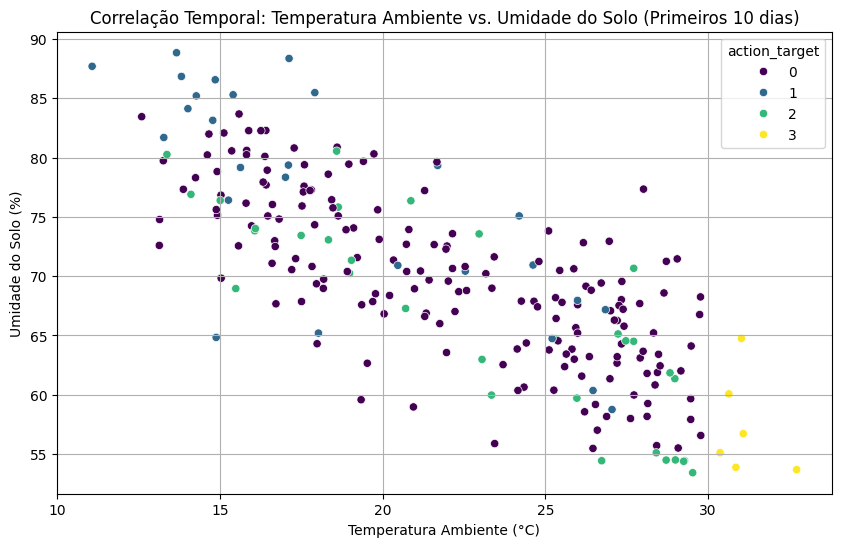

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_morango.iloc[:240], x='ambient_temperature', y='soil_moisture', hue='action_target', palette='viridis')
plt.title('Correlação Temporal: Temperatura Ambiente vs. Umidade do Solo (Primeiros 10 dias)')
plt.xlabel('Temperatura Ambiente (°C)')
plt.ylabel('Umidade do Solo (%)')
plt.grid(True)
plt.show()